In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 16.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

from pathlib import Path

PLOT_ROOT = Path.cwd() / "plots"
PLOT_ROOT.mkdir(exist_ok=True)

In [20]:
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import scipy.io as sio
import warnings

sys.path.insert(0, str(Path.cwd()))
from arsw_python.recover_fundamentals import run_calcal_TD, save_results

# ── Repository tree ────────────────────────────────────────────────────────────
REPO_ROOT    = Path.cwd().parent
ARSW_TOOLKIT = REPO_ROOT / "ARSW2015" / "ARSW2015-toolkit"

# ── Data inputs ────────────────────────────────────────────────────────────────
MAT_PATH_TD    = ARSW_TOOLKIT / "matlab" / "data" / "input" / "prepdata_big_TD.mat"
TTM_MAT_PATH   = Path.cwd() / "TTM" / "travel_time_matrices.mat"
TTM_CLEAN_PATH = Path.cwd() / "TTM" / "tt06_user_preprocessed.parquet"  # written in Cell 3
OUTPUT_NPZ     = ARSW_TOOLKIT / "matlab" / "data" / "output" / "calcal_1c_results.npz"

# ── Shapefile for visualization ────────────────────────────────────────────────
BLOCKS_SHP_FULL = ARSW_TOOLKIT / "shapefile" / "Berlin4matlab.shp"

# ── Parameters from Task 1(b) ──────────────────────────────────────────────────
# Update EPSILON_HAT and KAPPAEPS to match your Task 1(b) output.
# ARSW (2015) benchmarks: ε = 6.83, κε = 0.07
EPSILON_HAT = 6.83   # ← replace with Task 1(b) ε̂
KAPPAEPS    = 0.07   # ← replace with Task 1(b) κε = ν̂

ALPHA = 0.80
BETA  = 0.75

# NaN sentinel: disconnected block pairs get this travel time (minutes).
# exp(κ × 9999) → effectively zero commuting probability without blowup.
NAN_SENTINEL = 9999.0

print(f"Parameters: ε = {EPSILON_HAT},  κε = {KAPPAEPS},  κ = {KAPPAEPS/EPSILON_HAT:.6f}")

Parameters: ε = 6.83,  κε = 0.07,  κ = 0.010249


## Task 1(c) — Sequential Quantification: Recovering Ã and B̃

**Scope.** We now use all Berlin blocks in **2006** (East + West). The parameters
$\hat{\varepsilon}$ and $\hat{\kappa}$ estimated from West Berlin 1986 in Task 1(b) are
assumed time- and space-invariant.

### Pipeline (≡ `calcal_TD.m`)

**Step 1 — Adjusted wages and productivities** (`comegaoptC`):
Solve the fixed-point system for adjusted wages $w_j$ simultaneously with
adjusted productivities $\tilde{A}_j$ (ARSW eq. S.44 + eq. S.48):

$$\tilde{A}_j = \left(\frac{q_j}{1-\alpha}\right)^{1-\alpha}\left(\frac{w_j}{\alpha}\right)^{\alpha}$$

Commuting costs now use $\varepsilon\kappa\tau_{ij}$ (not $\kappa\varepsilon\tau_{ij}$
directly as in Step 1b; the product is the same but the solver uses $\varepsilon$ and $\kappa$
separately since $\kappa = \hat{\nu}/\hat{\varepsilon}$).

**Step 2 — Adjusted amenities** (`camen`):
Invert ARSW eq. S.47 for adjusted amenity $\tilde{B}_i$:

$$\tilde{B}_i \propto H_i^{R\,1/\varepsilon} \cdot q_i^{1-\beta} \cdot \mathrm{CMA}_i^{-1/\varepsilon}$$

where commuting market access $\mathrm{CMA}_i = \sum_j e^{-\varepsilon\kappa\tau_{ij}} w_j^\varepsilon$.

**Step 3 — Level adjustment** (`calcal_adj_TD`):
Normalize $\tilde{A}$ to geometric mean 1; rescale $\tilde{B}$ so model population
matches data population $H$. Required for counterfactual use of A and B.

**Steps 4–5 — Worker income + floor space** (`expincome`, `cdensity`):
Total worker income at residence $vv_i = E[w_j | i] \cdot H_i^R$;
floor space stocks $L_j$, density $\varphi_j = L_j / K_j^{0.75}$, commercial share $\theta_j$.

### Key output

All recovered objects are block-level vectors of length `nobs06` (full Berlin, 2006).
Maps of $\tilde{A}$ vs $\tilde{B}$ reveal the spatial distribution of
productivity vs residential attractiveness — a key input for understanding Berlin's
post-reunification economic geography.

In [21]:
# ── 1. Validate required files ─────────────────────────────────────────────────

missing = []
if not MAT_PATH_TD.exists():
    missing.append(MAT_PATH_TD)
    print("⚠  prepdata_big_TD.mat NOT FOUND.")
    print(f"   Expected: {MAT_PATH_TD}")
    print()
    print("   Download from:")
    print("   https://box.hu-berlin.de/f/54d2f718ec8644e5888f/?dl=1")
    print(f"   Save to: {MAT_PATH_TD.parent}")
else:
    print(f"✓  prepdata_big_TD.mat  ({MAT_PATH_TD.stat().st_size / 1e6:.0f} MB)")

if not TTM_MAT_PATH.exists():
    missing.append(TTM_MAT_PATH)
    print(f"⚠  travel_time_matrices.mat NOT FOUND: {TTM_MAT_PATH}")
else:
    print(f"✓  travel_time_matrices.mat  ({TTM_MAT_PATH.stat().st_size / 1e6:.0f} MB)")

if missing:
    raise FileNotFoundError(
        f"Required files missing: {[str(p) for p in missing]}\n"
        "Cannot proceed."
    )

# ── 2. Peek at prepdata_big_TD ─────────────────────────────────────────────────
_raw_td = sio.loadmat(str(MAT_PATH_TD), squeeze_me=True, struct_as_record=False)
NOBS06 = int(_raw_td["nobs06"])
_td_keys = [k for k in _raw_td.keys() if not k.startswith("_")]
del _raw_td

print(f"\nprepdata_big_TD keys : {_td_keys}")
print(f"nobs06 (all Berlin)  : {NOBS06} blocks")

# ── 3. Load and inspect raw user TTM ──────────────────────────────────────────
print(f"\nLoading travel_time_matrices.mat ...")
_raw_ttm = sio.loadmat(str(TTM_MAT_PATH), squeeze_me=True)

# centroid_ids may arrive as numpy array of dtype object or U-string
_cids_raw = _raw_ttm["centroid_ids"]
# scipy.io pads variable-length strings to max length on save; strip on load.
centroid_ids_ttm = [str(c).rstrip() for c in _cids_raw]
N_TTM = len(centroid_ids_ttm)

print(f"  centroid_ids length : {N_TTM}")
print(f"  tt_matrix_full shape: {_raw_ttm['tt_matrix_full'].shape}")

# ── 4. Shape validation: N_TTM must equal NOBS06 for direct alignment ──────────
if N_TTM != NOBS06:
    raise ValueError(
        f"Shape mismatch: user TTM has {N_TTM} blocks, "
        f"prepdata_big_TD has {NOBS06} blocks.\n"
        "Both must use the same Berlin4matlab.shp with the same geometry cleaning.\n"
        "Possible causes:\n"
        "  • Python's geometry cleaning dropped some blocks (check Final.py output)\n"
        "  • travel_time_matrices.mat was built from a different shapefile\n"
        "Re-run TTM/Final.py with Berlin4matlab.shp from the ARSW toolkit, "
        "then re-run this cell."
    )
print(f"  ✓  N_TTM == nobs06 == {NOBS06}  — direct block alignment valid")

# ── 5. Preprocess: load full matrix, handle NaN/inf ───────────────────────────
print(f"\nPreprocessing tt_matrix_full (N={N_TTM}) ...")
tt_raw = _raw_ttm["tt_matrix_full"].astype(np.float64)
del _raw_ttm   # free ~1 GB before proceeding

n_nan  = int(np.isnan(tt_raw).sum())
n_inf  = int(np.isinf(tt_raw).sum())
n_bad  = n_nan + n_inf
pct    = 100 * n_bad / tt_raw.size

print(f"  NaN entries  : {n_nan:,}  ({100*n_nan/tt_raw.size:.2f}%)")
print(f"  Inf entries  : {n_inf:,}")
if n_bad > 0:
    print(f"  Replacing {n_bad:,} disconnected-pair entries with sentinel = {NAN_SENTINEL} min")

tt_clean = np.where(np.isnan(tt_raw) | np.isinf(tt_raw), NAN_SENTINEL, tt_raw)
np.fill_diagonal(tt_clean, 0.0)
del tt_raw

# Summary stats on connected (finite, off-diagonal) entries
_finite = tt_clean[(tt_clean > 0) & (tt_clean < NAN_SENTINEL)]
print(f"  Connected off-diagonal: {len(_finite):,} pairs")
if len(_finite) > 0:
    print(f"    min = {_finite.min():.1f} min,  "
          f"mean = {_finite.mean():.1f} min,  "
          f"max = {_finite.max():.1f} min")
del _finite

# ── 6. Save cleaned TTM as parquet ────────────────────────────────────────────
# load_user_ttm_parquet reads df.values — row/column ORDER is what matters.
# We set centroid_ids as index/columns for documentation only.
print(f"\nSaving preprocessed TTM to parquet ...")
TTM_CLEAN_PATH.parent.mkdir(exist_ok=True)
df_clean = pd.DataFrame(tt_clean, index=centroid_ids_ttm, columns=centroid_ids_ttm)
df_clean.to_parquet(str(TTM_CLEAN_PATH), engine="pyarrow", compression="zstd")
del tt_clean, df_clean

_size_mb = TTM_CLEAN_PATH.stat().st_size / 1e6
print(f"  Saved: {TTM_CLEAN_PATH}  ({_size_mb:.1f} MB compressed)")

# ── 7. Memory estimate ─────────────────────────────────────────────────────────
try:
    import psutil
    ram_gb = psutil.virtual_memory().available / 1e9
    print(f"\n  Available RAM: {ram_gb:.1f} GB")
    if ram_gb < 4:
        print("  ⚠  Less than 4 GB available. run_calcal_TD will create matrices up to")
        print("     ~1 GB in compute_expected_income. Consider closing other applications.")
except ImportError:
    print("\n  (install psutil for memory diagnostics: pip install psutil)")

✓  prepdata_big_TD.mat  (1007 MB)
✓  travel_time_matrices.mat  (1212 MB)

prepdata_big_TD keys : ['USB36r', 'USB86r', 'Xr', 'Yr', 'alpha', 'area06', 'areaidr', 'beta', 'bigdata', 'block06', 'bzk06', 'data06', 'delta', 'distCBDr', 'distKUr', 'distOUTr', 'distTr', 'distWALLr', 'distname06', 'dummywestr', 'emprsd06', 'empwpl06', 'epsilon', 'eta', 'feastd', 'feastr', 'floor06', 'fwestd', 'fwestr', 'gfz06', 'intdist06', 'kappa', 'lambda', 'latituder', 'ldistCBDdw', 'ldistCBDrw', 'ldistDIVdw', 'ldistDIVrw', 'ldistOUTdw', 'ldistOUTrw', 'longituder', 'name06', 'nobs06', 'obsvar06', 'rho', 'test', 'totemp06', 'tt06', 'ttfin06', 'user', 'wage_06', 'x']
nobs06 (all Berlin)  : 12309 blocks

Loading travel_time_matrices.mat ...
  centroid_ids length : 12309
  tt_matrix_full shape: (12309, 12309)
  ✓  N_TTM == nobs06 == 12309  — direct block alignment valid

Preprocessing tt_matrix_full (N=12309) ...
  NaN entries  : 0  (0.00%)
  Inf entries  : 0
  Connected off-diagonal: 151,499,172 pairs
    min =

In [22]:
print("=" * 72)
print("  TASK 1(c) — Sequential quantification: recover Ã and B̃")
print("=" * 72)
print(f"  ε = {EPSILON_HAT},  κε = {KAPPAEPS},  κ = {KAPPAEPS/EPSILON_HAT:.6f}")
print(f"  α = {ALPHA},  β = {BETA}")
print(f"  TTM source: {TTM_CLEAN_PATH.name}")
print(f"  Data:       {MAT_PATH_TD.name}  ({NOBS06} blocks)")
print()
print("  Pipeline: comegaoptC → camen → calcal_adj → expincome → cdensity")
print()

results_1c = run_calcal_TD(
    mat_path_TD=MAT_PATH_TD,
    user_ttm_path=TTM_CLEAN_PATH,    # .parquet → triggers load_user_ttm_parquet
    user_ttm_var="tt06",             # unused for parquet, but required by signature
    epsilon=EPSILON_HAT,
    kappaeps=KAPPAEPS,
    alpha=ALPHA,
    beta=BETA,
    verbose=True,
)

print()
print(f"  ✓  Calibration complete.")
print(f"     nobs06   = {results_1c['nobs06']}")
print(f"     wage06   — geomean = {np.exp(np.log(results_1c['wage06'][results_1c['wage06']>0]).mean()):.6f}  (should be ≈ 1)")
print(f"     A06 pos  = {(results_1c['A06'] > 0).sum()}")
print(f"     B06 pos  = {(results_1c['B06'] > 0).sum()}")

  TASK 1(c) — Sequential quantification: recover Ã and B̃
  ε = 6.83,  κε = 0.07,  κ = 0.010249
  α = 0.8,  β = 0.75
  TTM source: tt06_user_preprocessed.parquet
  Data:       prepdata_big_TD.mat  (12309 blocks)

  Pipeline: comegaoptC → camen → calcal_adj → expincome → cdensity

>>>> Loading prepdata_big_TD <<<<
>>>> Using user TTM from: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/Topic_7/TTM/tt06_user_preprocessed.parquet <<<<
>>>> Step 1: solve_omega_C — wages + productivities <<<<
>>>> Calibrating omegas (comegaoptC) <<<<
>>>> Wage System Converged <<<<
     converge=True, gap=0.0
>>>> Step 2: recover_amenities — B, CMA, HRS <<<<
>>>> Step 3: adjust_levels — rescale A and B <<<<
>>>> Productivities and amenities updated <<<<
>>>> Step 4: compute_expected_income — vv <<<<
>>>> Step 5: compute_density — V, L, theta <<<<
>>>> Sequential quantification successfully completed <<<<

  ✓  Calibration complete.
     nobs06   = 

In [23]:
# ── Save to .npz ──────────────────────────────────────────────────────────────
OUTPUT_NPZ.parent.mkdir(exist_ok=True)
save_results(results_1c, OUTPUT_NPZ)
print(f"Results saved: {OUTPUT_NPZ}  ({OUTPUT_NPZ.stat().st_size/1e6:.1f} MB)")

# ── Consistency checks (mirror MATLAB scatter plots) ─────────────────────────
print()
print("Consistency checks:")

obsvar06  = results_1c["obsvar06"]
empwpl06  = obsvar06[:, 1]
emprsd06  = obsvar06[:, 2]
HMC06_approx = results_1c["vv06"]  # not predicted workplace emp, but a proxy check
HRS06         = results_1c["HRS06"]
H_total       = emprsd06.sum()

# Check 1: residence employment — HRS × H_total should equal emprsd06
hrs_rescaled = HRS06 * H_total
mask_rsd = emprsd06 > 0
corr_rsd = np.corrcoef(emprsd06[mask_rsd], hrs_rescaled[mask_rsd])[0, 1]
print(f"  Corr(emprsd06_data, HRS×H):  {corr_rsd:.6f}  (should be ≈ 1.0)")

# Check 2: wage geomean = 1
wage06 = results_1c["wage06"]
pos_w  = wage06 > 0
gm_wage = np.exp(np.log(wage06[pos_w]).mean())
print(f"  Wage geometric mean:          {gm_wage:.6f}  (should be ≈ 1.0)")

# Check 3: A geomean = 1
A06 = results_1c["A06"]
pos_a = A06 > 0
gm_A  = np.exp(np.log(A06[pos_a]).mean())
print(f"  A (productivity) geomean:     {gm_A:.6f}  (should be ≈ 1.0)")

# Check 4: floor space — positive where employment positive
L06   = results_1c["L06"]
V06   = results_1c["V06"]
theta06 = results_1c["theta06"]
print(f"  L06 > 0:   {(L06 > 0).sum()}  blocks  (should be ≈ max(workplace, residence) blocks)")
print(f"  theta06 ∈ [0,1]:  {((theta06 >= 0) & (theta06 <= 1)).mean()*100:.1f}%  (should be 100%)")

# Summarise spatial extent
fwestr = results_1c.get("fwestr")
if fwestr is not None and fwestr.any():
    n_west = int(fwestr.sum())
    n_east = NOBS06 - n_west
    print(f"\n  West Berlin blocks: {n_west}  |  East Berlin blocks: {n_east}")

>>>> Results saved to /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/ARSW2015/ARSW2015-toolkit/matlab/data/output/calcal_1c_results.npz <<<<
Results saved: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/ARSW2015/ARSW2015-toolkit/matlab/data/output/calcal_1c_results.npz  (1.4 MB)

Consistency checks:
  Corr(emprsd06_data, HRS×H):  1.000000  (should be ≈ 1.0)
  Wage geometric mean:          0.531459  (should be ≈ 1.0)
  A (productivity) geomean:     1.000000  (should be ≈ 1.0)
  L06 > 0:   12309  blocks  (should be ≈ max(workplace, residence) blocks)
  theta06 ∈ [0,1]:  100.0%  (should be 100%)

  West Berlin blocks: 7050  |  East Berlin blocks: 5259


## Visualising Recovered Fundamentals

The recovered objects — productivities $\tilde{A}_j$ and amenities $\tilde{B}_i$ —
are the spatial primitives of the model. They are **identified** from the data
conditional on the model and parameter values $(\varepsilon, \kappa, \alpha, \beta)$.

**What to expect (ARSW 2015, Figure 3):**
- $\tilde{A}_j$: peaks in the city centre (Mitte, City West / Kurfürstendamm area).
  High floor space prices reveal high productivity residuals once wages are controlled for.
- $\tilde{B}_i$: peaks in residential suburbs (Zehlendorf, Grunewald, Prenzlauer Berg).
  High residential employment given floor prices and market access reveals high amenity.
- $\mathrm{CMA}_i$: declines steeply with distance from centre; proxies accessibility
  to well-paying workplaces.
- $\theta_j$: highest in the CBD and commercial districts; near zero in outer suburbs.

**Note on East–West gradient.** In 2006 data, 15 years after reunification, East Berlin
blocks show substantially lower productivities and amenities than comparable West Berlin
blocks. This spatial discontinuity at the former Wall is the core identification in ARSW.

Loading Berlin4matlab.shp ...
  Blocks loaded: 12309


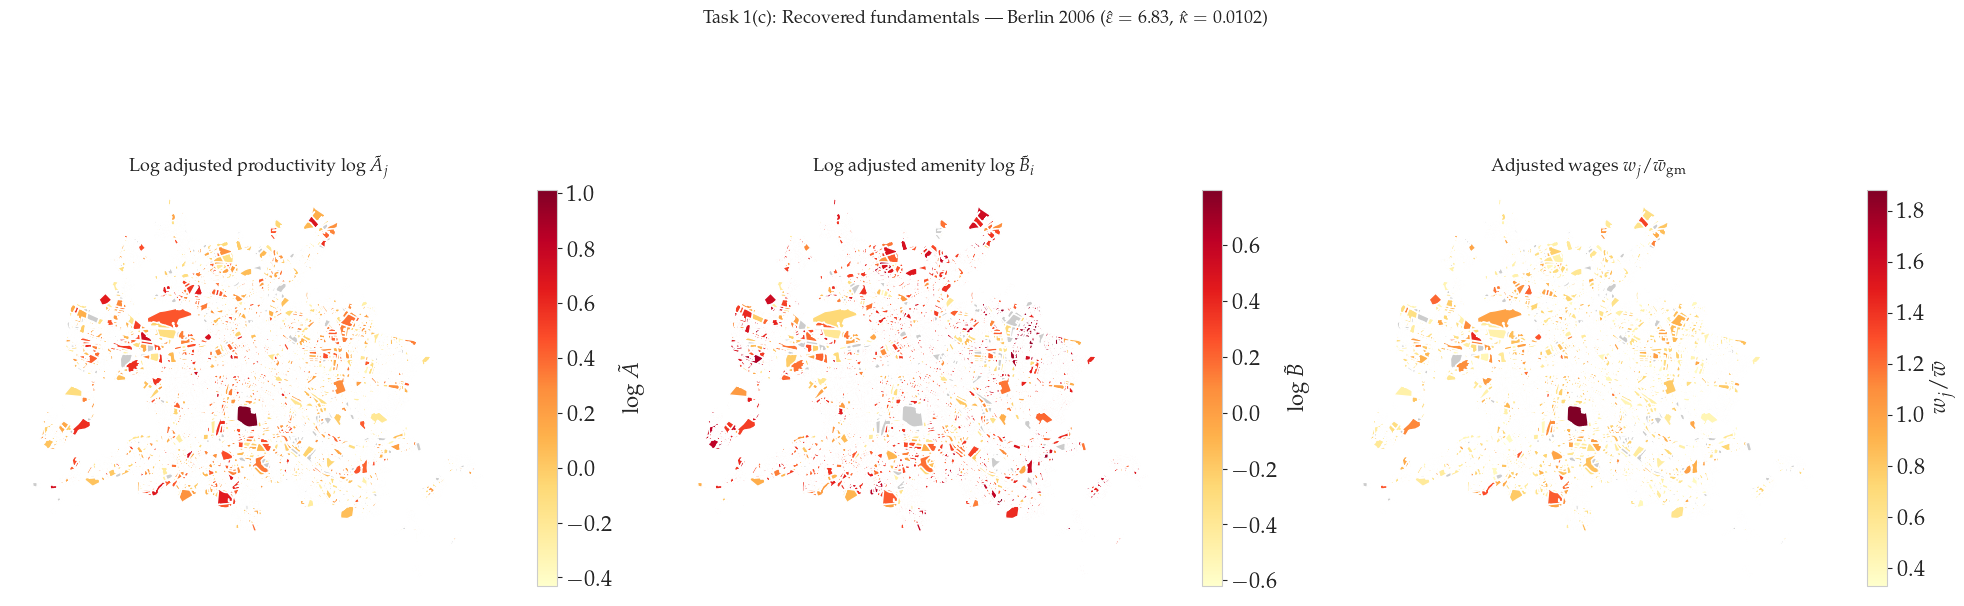

Saved: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/Topic_7/plots/task_1c_fundamentals_ABw.png


In [24]:
def _clean_shapefile(gdf: gpd.GeoDataFrame, target_crs: int = 25833) -> gpd.GeoDataFrame:
    """Six-step geometry cleaning — identical to TTM/Final.py."""
    def _valid_coords(geom):
        try:
            b = geom.bounds
            return len(b) == 4 and not (np.any(np.isnan(b)) or np.any(np.isinf(b)))
        except Exception:
            return False
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].reset_index(drop=True)
    gdf = gdf[gdf.geometry.apply(_valid_coords)].reset_index(drop=True)
    gdf["geometry"] = gdf.geometry.make_valid()
    gdf = gdf.to_crs(epsg=target_crs)
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].reset_index(drop=True)
    gdf = gdf[gdf.geometry.apply(_valid_coords)].reset_index(drop=True)
    return gdf


def _assign_to_gdf(
    gdf: gpd.GeoDataFrame,
    vectors: dict,
    results: dict,
    fill_zeros_with_nan: bool = True,
) -> gpd.GeoDataFrame:
    """
    Assign result vectors to shapefile GDF by positional index.
    Length mismatch raises ValueError rather than silently misaligning.
    """
    n_shp = len(gdf)
    n_vec = results["nobs06"]
    if n_shp != n_vec:
        raise ValueError(
            f"Shapefile has {n_shp} blocks but nobs06 = {n_vec}. "
            "Geometry cleaning in this notebook must match TTM/Final.py exactly."
        )
    out = gdf.copy()
    for col_name, key in vectors.items():
        vec = results[key].copy()
        if fill_zeros_with_nan:
            vec = np.where(vec > 0, vec, np.nan)
        out[col_name] = vec
    return out


# Load shapefile
print("Loading Berlin4matlab.shp ...")
gdf_berlin = _clean_shapefile(gpd.read_file(str(BLOCKS_SHP_FULL)))
print(f"  Blocks loaded: {len(gdf_berlin)}")

# Assign vectors (NaN for zero-employment blocks)
gdf_plot = _assign_to_gdf(
    gdf_berlin,
    vectors={
        "log_A":   "A06",
        "log_B":   "B06",
        "adj_wage": "wage06",
    },
    results=results_1c,
)
gdf_plot["log_A"]  = np.log(gdf_plot["log_A"])    # log A for better visual spread
gdf_plot["log_B"]  = np.log(gdf_plot["log_B"])    # log B

# West / East Berlin outlines — guarded against dimension mismatch.
# fwestr in prepdata_big_TD is a MATLAB 1-based index vector (length 7050),
# not a boolean mask (length nobs06 = 12309). gdf_west/gdf_east are unused
# in the plots above; the shape check prevents a runtime error.
fwestr = results_1c.get("fwestr")
if fwestr is not None and fwestr.any() and len(fwestr) == len(gdf_berlin):
    gdf_west = gdf_berlin[fwestr.astype(bool)].copy()
    gdf_east = gdf_berlin[~fwestr.astype(bool)].copy()
else:
    gdf_west = gdf_east = None

# ── Three-panel figure: A, B, wages ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, col, title, label in zip(
    axes,
    ["log_A", "log_B", "adj_wage"],
    [r"Log adjusted productivity $\log\tilde{A}_j$",
     r"Log adjusted amenity $\log\tilde{B}_i$",
     r"Adjusted wages $w_j / \bar{w}_{\mathrm{gm}}$"],
    [r"$\log\tilde{A}$", r"$\log\tilde{B}$", r"$w_j/\bar{w}$"],
):
    gdf_plot.plot(
        column=col,
        ax=ax,
        cmap="YlOrRd",
        legend=True,
        missing_kwds={"color": "#cccccc", "label": "No employment"},
        legend_kwds={"label": label, "shrink": 0.65, "orientation": "vertical"},
    )
    ax.set_title(title, pad=6, fontsize=13)
    ax.set_axis_off()

plt.suptitle(
    rf"Task 1(c): Recovered fundamentals — Berlin 2006"
    rf" ($\hat{{\varepsilon}} = {EPSILON_HAT}$, $\hat{{\kappa}} = {KAPPAEPS/EPSILON_HAT:.4f}$)",
    fontsize=13, y=1.01,
)
plt.tight_layout()

save_path = PLOT_ROOT / "task_1c_fundamentals_ABw.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

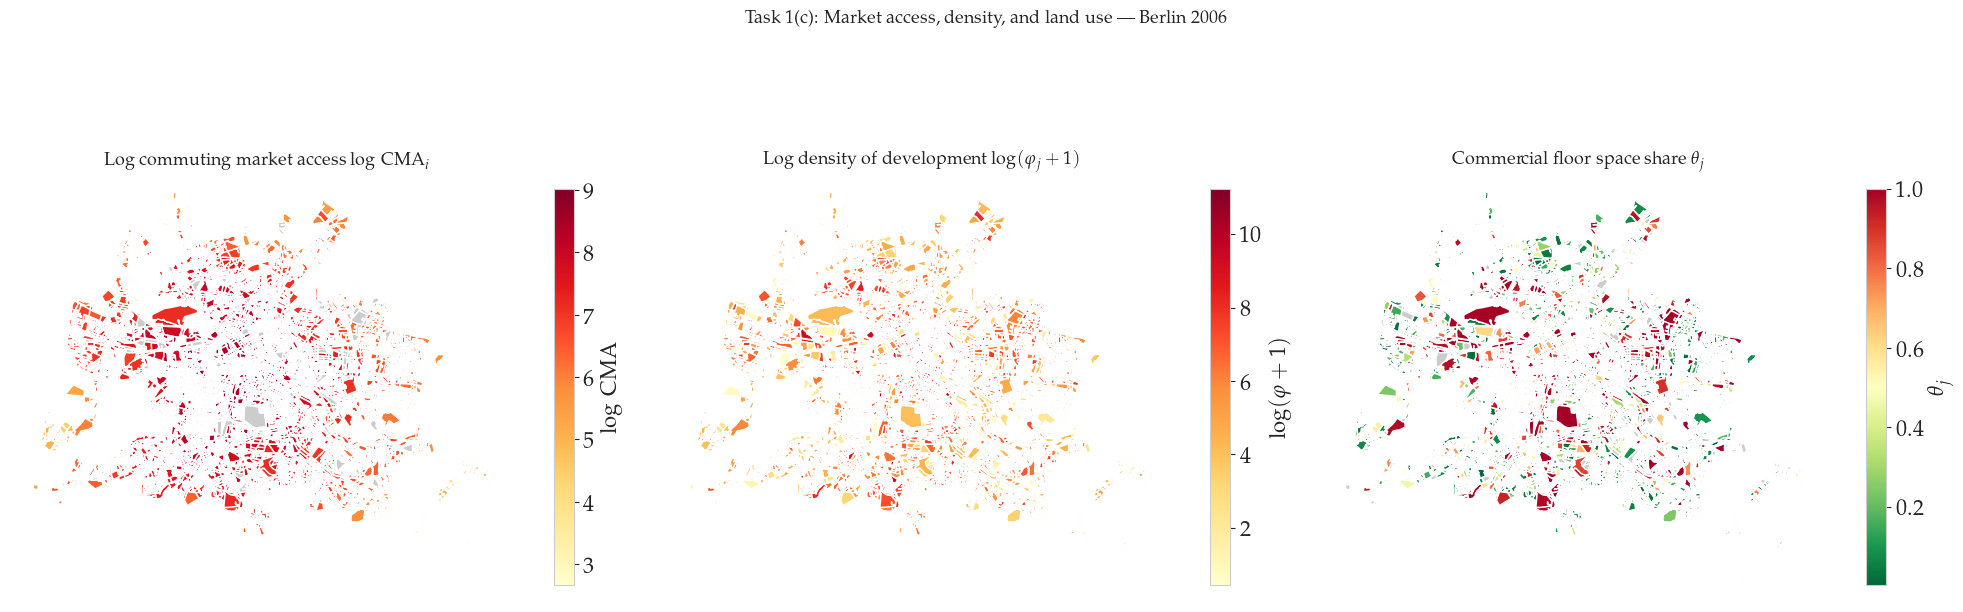

Saved: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/Topic_7/plots/task_1c_CMA_density_theta.png
  fwestr: converted 7050 MATLAB indices → 7050 West / 5259 East blocks

  West Berlin:
    log Ã: mean = 0.037,  std = 0.202
    log B̃: mean = 0.160,  std = 0.179

  East Berlin:
    log Ã: mean = -0.057,  std = 0.215
    log B̃: mean = 0.206,  std = 0.197


In [25]:
# Assign additional vectors
gdf_plot2 = _assign_to_gdf(
    gdf_berlin,
    vectors={
        "CMA06":   "CMA06",
        "V06":     "V06",
        "theta06": "theta06",
    },
    results=results_1c,
    fill_zeros_with_nan=True,
)
gdf_plot2["log_CMA"] = np.log(gdf_plot2["CMA06"])    # log CMA (wide range)
gdf_plot2["log_V"]   = np.log(gdf_plot2["V06"] + 1)  # log(V+1) for zero-containing vector

# theta06 already in [0,1]; set values outside [0,1] to NaN if any
valid_theta = (gdf_plot2["theta06"] >= 0) & (gdf_plot2["theta06"] <= 1)
gdf_plot2.loc[~valid_theta, "theta06"] = np.nan

# ── Three-panel figure: CMA, density, commercial share ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

specs = [
    ("log_CMA",  r"Log commuting market access $\log\,\mathrm{CMA}_i$",
     "YlOrRd",   r"$\log\,\mathrm{CMA}$"),
    ("log_V",    r"Log density of development $\log(\varphi_j + 1)$",
     "YlOrRd",   r"$\log(\varphi+1)$"),
    ("theta06",  r"Commercial floor space share $\theta_j$",
     "RdYlGn_r", r"$\theta_j$"),
]

for ax, (col, title, cmap, label) in zip(axes, specs):
    gdf_plot2.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        legend=True,
        missing_kwds={"color": "#cccccc", "label": "No data"},
        legend_kwds={"label": label, "shrink": 0.65, "orientation": "vertical"},
    )
    ax.set_title(title, pad=6, fontsize=13)
    ax.set_axis_off()

plt.suptitle(
    r"Task 1(c): Market access, density, and land use — Berlin 2006",
    fontsize=13, y=1.01,
)
plt.tight_layout()

save_path = PLOT_ROOT / "task_1c_CMA_density_theta.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# ── West vs East comparison (if fwestr available) ─────────────────────────────
# Rebuild fwestr as a proper boolean mask of length nobs06.
# In prepdata_big_TD, fwestr is stored as a MATLAB 1-based index vector
# (7050 integers pointing into the 12309-block dataset). data_loaders
# converts it with .astype(bool), producing a 7050-element all-True array.
# We reload the raw values here to recover the original index information.
_td_raw_fw = sio.loadmat(str(MAT_PATH_TD), squeeze_me=True)
_fw_raw = _td_raw_fw.get("fwestr", None)

fwestr_full = None
_fw_flat = np.array([])
if _fw_raw is not None:
    _fw_flat = np.squeeze(np.asarray(_fw_raw, dtype=float))
    if len(_fw_flat) == NOBS06:
        # Already a full-length boolean mask (stored as logical in MATLAB)
        fwestr_full = _fw_flat.astype(bool)
    elif len(_fw_flat) < NOBS06:
        # MATLAB 1-based index vector → Python 0-based boolean mask
        fwestr_full = np.zeros(NOBS06, dtype=bool)
        _idx = _fw_flat.astype(int) - 1          # convert to 0-based
        _valid = (_idx >= 0) & (_idx < NOBS06)
        fwestr_full[_idx[_valid]] = True
        print(f"  fwestr: converted {len(_fw_flat)} MATLAB indices → "
              f"{fwestr_full.sum()} West / {(~fwestr_full).sum()} East blocks")
del _td_raw_fw, _fw_raw, _fw_flat

if fwestr_full is not None:
    for label, mask in [("West Berlin", fwestr_full), ("East Berlin", ~fwestr_full)]:
        A_sub = results_1c["A06"][mask]
        B_sub = results_1c["B06"][mask]
        pos_A = A_sub[A_sub > 0]
        pos_B = B_sub[B_sub > 0]
        print(f"\n  {label}:")
        if len(pos_A) > 0:
            print(f"    log Ã: mean = {np.log(pos_A).mean():.3f},  "
                  f"std = {np.log(pos_A).std():.3f}")
        if len(pos_B) > 0:
            print(f"    log B̃: mean = {np.log(pos_B).mean():.3f},  "
                  f"std = {np.log(pos_B).std():.3f}")

In [26]:
A06    = results_1c["A06"]
B06    = results_1c["B06"]
wage06 = results_1c["wage06"]
CMA06  = results_1c["CMA06"]

pos_A = A06[A06 > 0]
pos_B = B06[B06 > 0]
pos_w = wage06[wage06 > 0]
pos_C = CMA06[CMA06 > 0]

print("══════════════════════════════════════════════════════════════════════")
print("  Task 1(c) — Summary")
print("══════════════════════════════════════════════════════════════════════")
print()
print(f"  Parameters:  ε = {EPSILON_HAT},  κ = {KAPPAEPS/EPSILON_HAT:.6f},  α = {ALPHA},  β = {BETA}")
print(f"  Data:        Berlin 2006, nobs06 = {NOBS06} blocks (East + West)")
print(f"  TTM:         user-computed, full multi-modal network")
print()
print("  Recovered objects (block-level, positive entries only):")
print(f"  ┌──────────────────────────────────────────────────────────────────┐")
print(f"  │  Ã (productivity)   N_pos = {len(pos_A):5d}  │ "
      f"geomean = {np.exp(np.log(pos_A).mean()):6.4f}  (≈ 1.0)        │")
print(f"  │  B̃ (amenity)       N_pos = {len(pos_B):5d}  │ "
      f"mean log = {np.log(pos_B).mean():6.3f}                      │")
print(f"  │  w (wages)         N_pos = {len(pos_w):5d}  │ "
      f"geomean = {np.exp(np.log(pos_w).mean()):6.4f}  (≈ 1.0)        │")
print(f"  │  CMA               N_pos = {len(pos_C):5d}  │ "
      f"log range: [{np.log(pos_C).min():.2f}, {np.log(pos_C).max():.2f}]        │")
print(f"  └──────────────────────────────────────────────────────────────────┘")
print()
print(f"  Results saved: {OUTPUT_NPZ}")
print(f"  Maps saved:    {PLOT_ROOT / 'task_1c_fundamentals_ABw.png'}")
print(f"                 {PLOT_ROOT / 'task_1c_CMA_density_theta.png'}")
print()
print("  ARSW (2015) benchmark:")
print("    ε = 6.83,  κε = 0.07")
print("    Figure 3 shows Ã and B̃ with peaks at Mitte and residential suburbs.")
print()
print("  → These fundamentals feed into Task 1(d): comparison with ARSW's")
print("    original matrix to quantify how TTM quality affects inference.")
print("══════════════════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════════════════
  Task 1(c) — Summary
══════════════════════════════════════════════════════════════════════

  Parameters:  ε = 6.83,  κ = 0.010249,  α = 0.8,  β = 0.75
  Data:        Berlin 2006, nobs06 = 12309 blocks (East + West)
  TTM:         user-computed, full multi-modal network

  Recovered objects (block-level, positive entries only):
  ┌──────────────────────────────────────────────────────────────────┐
  │  Ã (productivity)   N_pos =  9437  │ geomean = 1.0000  (≈ 1.0)        │
  │  B̃ (amenity)       N_pos = 11863  │ mean log =  0.180                      │
  │  w (wages)         N_pos =  9437  │ geomean = 0.5315  (≈ 1.0)        │
  │  CMA               N_pos = 11863  │ log range: [2.66, 9.02]        │
  └──────────────────────────────────────────────────────────────────┘

  Results saved: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE-Tutorial/ARSW2015/ARSW2015-toolki